# NOAA Weather Data Analysis - JFK Airport (New York)

## Week 3: Statistical Analysis and Hypothesis Testing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, json

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

OUT = "figs"
os.makedirs(OUT, exist_ok=True)

# ---------- Load & prep ----------
df = pd.read_csv("jfk_weather_cleaned.csv")

df['DATE'] = pd.to_datetime(df['DATE'])
print("Shape:", df.shape)
print("Range:", df["DATE"].min(), "→", df["DATE"].max())

df["month"] = df["DATE"].dt.month
df["year"]  = df["DATE"].dt.year
df["hour"]  = df["DATE"].dt.hour

Shape: (114544, 16)
Range: 2010-01-01 01:00:00 → 2018-07-27 23:59:00


In [3]:
# Meteorological season
def season(m):
    if m in (12,1,2):  return "Winter"
    if m in (3,4,5):   return "Spring"
    if m in (6,7,8):   return "Summer"
    return "Autumn"
df["season"] = df["month"].apply(season)

# Coerce numerics
for c in ["dry_bulb_temp_f","wet_bulb_temp_f","relative_humidity","wind_speed",
          "sea_level_pressure","precip","visibility"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows without core measurements
core = df.dropna(subset=["dry_bulb_temp_f","relative_humidity","wind_speed",
                         "sea_level_pressure","visibility"]).copy()
print("After clean:", core.shape)

summary = core[["dry_bulb_temp_f","relative_humidity","wind_speed",
                "sea_level_pressure","visibility","precip"]].describe().round(2)
summary.to_csv("summary_stats.csv")
summary

After clean: (114544, 20)


,dry_bulb_temp_f,relative_humidity,wind_speed,sea_level_pressure,visibility,precip
count,114544.00,114544.00,114544.00,114544.00,114544.00,114544.00
mean,55.24,67.24,11.22,30.01,8.83,0.01
std,17.15,20.23,6.17,0.24,2.65,0.04
min,1.00,8.00,0.00,28.54,0.00,0.00
25%,42.00,51.00,7.00,29.87,9.94,0.00
50%,55.00,69.00,10.00,30.01,10.00,0.00
75%,70.00,85.00,15.00,30.16,10.00,0.00
max,102.00,100.00,53.00,30.85,10.00,2.41


### HYPOTHESIS 1 — Two-sample t-test
* **H0: Mean summer temp = Mean winter temp**
* **H1: Mean summer temp ≠ Mean winter temp**

In [4]:
summer = core.loc[core["season"]=="Summer","dry_bulb_temp_f"].dropna()
winter = core.loc[core["season"]=="Winter","dry_bulb_temp_f"].dropna()

# Welch's t-test (unequal variances)
t_stat, t_p = stats.ttest_ind(summer, winter, equal_var=False)
# 95% CI for difference of means (Welch)
mean_diff = summer.mean() - winter.mean()
se = np.sqrt(summer.var(ddof=1)/len(summer) + winter.var(ddof=1)/len(winter))
dfree = (se**4) / ((summer.var(ddof=1)/len(summer))**2/(len(summer)-1)
                   + (winter.var(ddof=1)/len(winter))**2/(len(winter)-1))
tcrit = stats.t.ppf(0.975, dfree)
ci_low, ci_high = mean_diff - tcrit*se, mean_diff + tcrit*se
# Cohen's d
pooled = np.sqrt(((len(summer)-1)*summer.var(ddof=1)+(len(winter)-1)*winter.var(ddof=1))
                 /(len(summer)+len(winter)-2))
cohen_d = mean_diff / pooled

t_result = dict(n_summer=len(summer), n_winter=len(winter),
                mean_summer=round(summer.mean(),3), mean_winter=round(winter.mean(),3),
                mean_diff=round(mean_diff,3),
                t_stat=round(t_stat,3), df=round(dfree,1),
                p_value=t_p, ci95=(round(ci_low,3), round(ci_high,3)),
                cohen_d=round(cohen_d,3))
print("\n=== T-test (Summer vs Winter Temperature) ===")
print(json.dumps(t_result, default=str, indent=2))


=== T-test (Summer vs Winter Temperature) ===
{
  "n_summer": 28653,
  "n_winter": 29071,
  "mean_summer": 74.472,
  "mean_winter": 36.488,
  "mean_diff": 37.984,
  "t_stat": 524.527,
  "df": 51960.4,
  "p_value": 0.0,
  "ci95": [
    37.842,
    38.126
  ],
  "cohen_d": 4.356
}


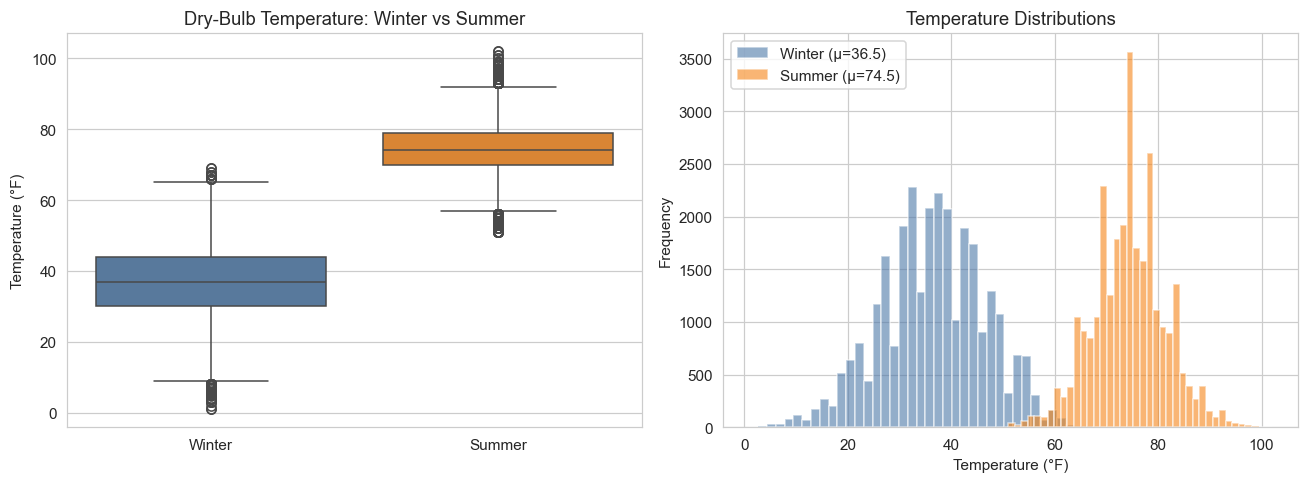

In [7]:
# Plot 1: Boxplot + histogram
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=core[core["season"].isin(["Summer","Winter"])],
            x="season", y="dry_bulb_temp_f",
            order=["Winter","Summer"], palette=["#4C78A8","#F58518"], 
            hue="season", legend=False, ax=ax[0])
ax[0].set_title("Dry-Bulb Temperature: Winter vs Summer")
ax[0].set_ylabel("Temperature (°F)"); ax[0].set_xlabel("")

ax[1].hist(winter, bins=40, alpha=0.6, label=f"Winter (μ={winter.mean():.1f})", color="#4C78A8")
ax[1].hist(summer, bins=40, alpha=0.6, label=f"Summer (μ={summer.mean():.1f})", color="#F58518")
ax[1].set_title("Temperature Distributions")
ax[1].set_xlabel("Temperature (°F)"); ax[1].set_ylabel("Frequency")
ax[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT}/fig1_ttest.png", bbox_inches="tight")
plt.show()
plt.close()

### HYPOTHESIS 2 — One-way ANOVA
* **H0: Mean wind_speed equal across four seasons**
* **H1: At least one season differs**

In [8]:
groups = [core.loc[core["season"]==s,"wind_speed"].dropna()
          for s in ["Winter","Spring","Summer","Autumn"]]
f_stat, f_p = stats.f_oneway(*groups)

# Effect size: eta-squared
all_vals = np.concatenate(groups)
grand = all_vals.mean()
ss_between = sum(len(g)*(g.mean()-grand)**2 for g in groups)
ss_total   = ((all_vals-grand)**2).sum()
eta_sq = ss_between/ss_total

In [9]:
# Post-hoc Tukey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd
sub = core[["season","wind_speed"]].dropna()
tuk = pairwise_tukeyhsd(sub["wind_speed"], sub["season"], alpha=0.05)
tuk_df = pd.DataFrame(data=tuk._results_table.data[1:], columns=tuk._results_table.data[0])
tuk_df.to_csv("tukey_wind.csv", index=False)

anova_result = dict(F=round(f_stat,3), p_value=f_p, eta_sq=round(eta_sq,4),
                    means={s: round(core.loc[core["season"]==s,"wind_speed"].mean(),2)
                           for s in ["Winter","Spring","Summer","Autumn"]})
print("\n=== ANOVA (Wind speed by season) ===")
print(json.dumps(anova_result, default=str, indent=2))
print(tuk_df)


=== ANOVA (Wind speed by season) ===
{
  "F": 972.64,
  "p_value": 0.0,
  "eta_sq": 0.0248,
  "means": {
    "Winter": 12.38,
    "Spring": 11.75,
    "Summer": 9.81,
    "Autumn": 10.86
  }
}
   group1  group2  meandiff  p-adj   lower   upper  reject
0  Autumn  Spring    0.8889    0.0  0.7572  1.0206    True
1  Autumn  Summer   -1.0518    0.0 -1.1856 -0.9180    True
2  Autumn  Winter    1.5198    0.0  1.3865  1.6532    True
3  Spring  Summer   -1.9407    0.0 -2.0692 -1.8122    True
4  Spring  Winter    0.6309    0.0  0.5029  0.7590    True
5  Summer  Winter    2.5716    0.0  2.4414  2.7018    True


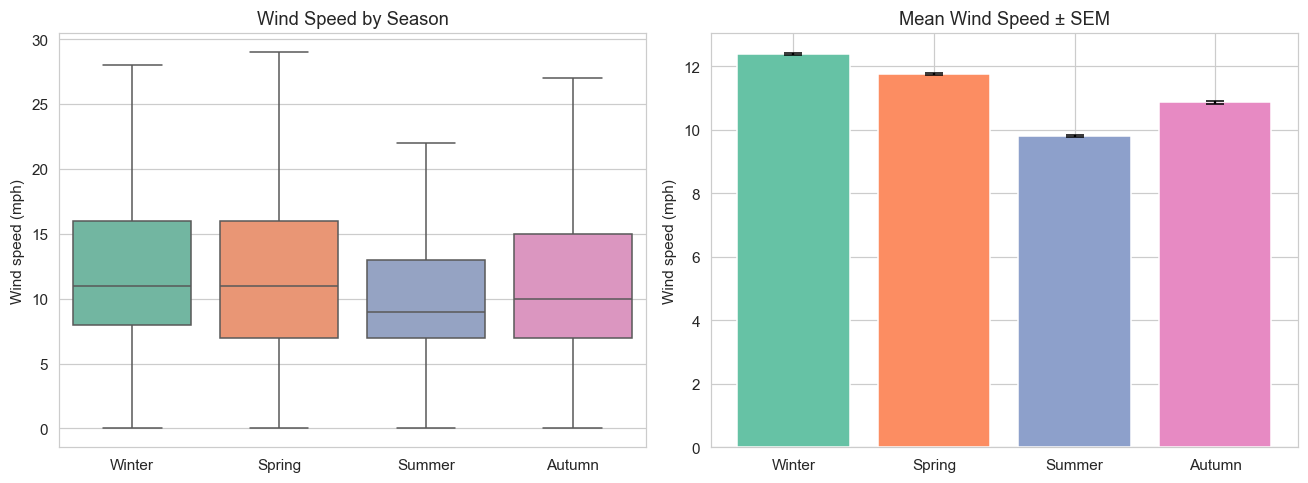

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=core, x="season", y="wind_speed",
            order=["Winter","Spring","Summer","Autumn"],
            palette="Set2", hue="season", legend=False, 
            ax=ax[0], showfliers=False)
ax[0].set_title("Wind Speed by Season"); ax[0].set_ylabel("Wind speed (mph)"); ax[0].set_xlabel("")

season_means = [g.mean() for g in groups]
season_sem   = [g.std(ddof=1)/np.sqrt(len(g)) for g in groups]
ax[1].bar(["Winter","Spring","Summer","Autumn"], season_means,
          yerr=season_sem, capsize=6, color=sns.color_palette("Set2"))
ax[1].set_title("Mean Wind Speed ± SEM"); ax[1].set_ylabel("Wind speed (mph)")
plt.tight_layout()
plt.savefig(f"{OUT}/fig2_anova.png", bbox_inches="tight")
plt.show()
plt.close()

### HYPOTHESIS 3 — Chi-square test of independence
* **H0: Low-visibility events are independent of season**
* **H1: Low-visibility events depend on season**

In [12]:
core["low_vis"] = np.where(core["visibility"] < 3, "LowVis (<3mi)", "Normal (≥3mi)")
ctab = pd.crosstab(core["season"], core["low_vis"])
ctab = ctab.reindex(["Winter","Spring","Summer","Autumn"])
chi2, chi_p, dof, expected = stats.chi2_contingency(ctab)
n = ctab.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ctab.shape)-1)))

chi_result = dict(chi2=round(chi2,3), df=int(dof), p_value=chi_p,
                  cramers_v=round(cramers_v,3),
                  observed=ctab.to_dict(), 
                  low_vis_rate={s: round(ctab.loc[s,"LowVis (<3mi)"]/ctab.loc[s].sum()*100,2)
                                for s in ctab.index})
print("\n=== Chi-square (Low visibility vs Season) ===")
print(ctab)
print(json.dumps(chi_result, default=str, indent=2))


=== Chi-square (Low visibility vs Season) ===
low_vis  LowVis (<3mi)  Normal (≥3mi)
season                               
Winter            3611          25460
Spring            3275          27403
Summer             947          27706
Autumn            1253          24889
{
  "chi2": 2311.046,
  "df": 3,
  "p_value": 0.0,
  "cramers_v": 0.142,
  "observed": {
    "LowVis (<3mi)": {
      "Winter": 3611,
      "Spring": 3275,
      "Summer": 947,
      "Autumn": 1253
    },
    "Normal (\u22653mi)": {
      "Winter": 25460,
      "Spring": 27403,
      "Summer": 27706,
      "Autumn": 24889
    }
  },
  "low_vis_rate": {
    "Winter": 12.42,
    "Spring": 10.68,
    "Summer": 3.31,
    "Autumn": 4.79
  }
}


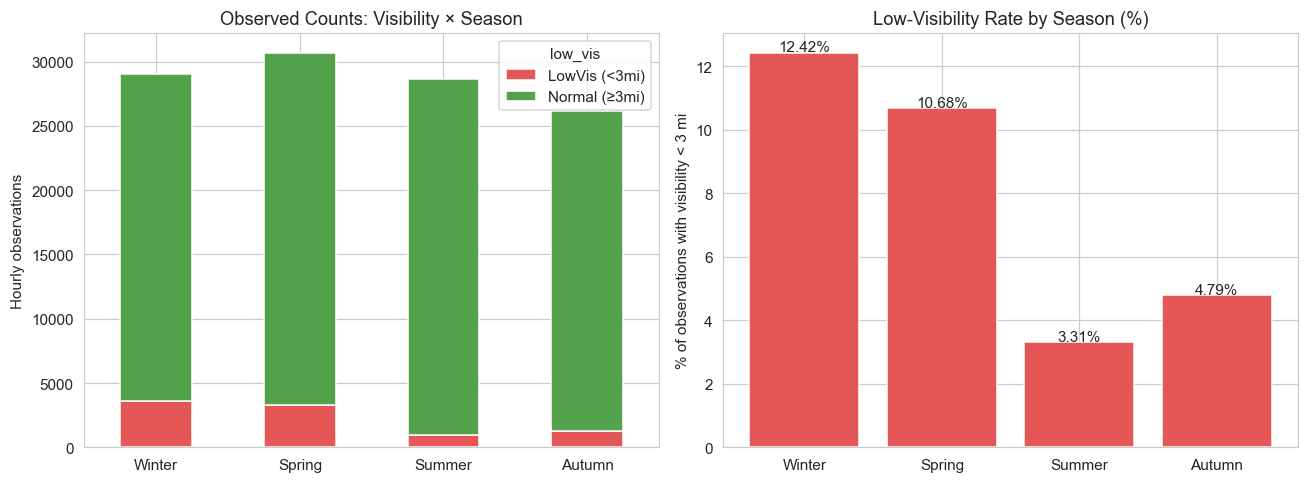

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
ctab.plot(kind="bar", stacked=True, ax=ax[0], color=["#E45756","#54A24B"])
ax[0].set_title("Observed Counts: Visibility × Season")
ax[0].set_ylabel("Hourly observations"); ax[0].set_xlabel("")
ax[0].tick_params(axis='x', rotation=0)

rates = [chi_result["low_vis_rate"][s] for s in ["Winter","Spring","Summer","Autumn"]]
ax[1].bar(["Winter","Spring","Summer","Autumn"], rates, color="#E45756")
ax[1].set_title("Low-Visibility Rate by Season (%)")
ax[1].set_ylabel("% of observations with visibility < 3 mi")
for i,v in enumerate(rates):
    ax[1].text(i, v+0.05, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.savefig(f"{OUT}/fig3_chi2.png", bbox_inches="tight")
plt.show()
plt.close()

### HYPOTHESIS 4 — Pearson correlation
* **H0: ρ(temperature, relative humidity) = 0**

In [15]:
sample = core[["dry_bulb_temp_f","relative_humidity"]].dropna().sample(
    n=min(20000, len(core)), random_state=42)
r, r_p = stats.pearsonr(sample["dry_bulb_temp_f"], sample["relative_humidity"])
corr_result = dict(pearson_r=round(r,4), p_value=r_p, n=len(sample))
print("\n=== Correlation (Temp vs RH) ===")
print(corr_result)


=== Correlation (Temp vs RH) ===
{'pearson_r': np.float64(0.1242), 'p_value': np.float64(1.4819684441372705e-69), 'n': 20000}


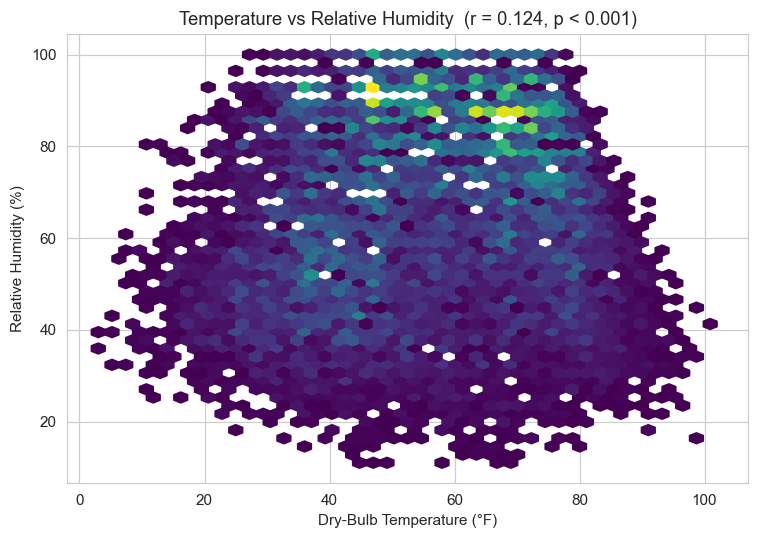

In [16]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hexbin(sample["dry_bulb_temp_f"], sample["relative_humidity"],
          gridsize=45, cmap="viridis", mincnt=1)
ax.set_xlabel("Dry-Bulb Temperature (°F)")
ax.set_ylabel("Relative Humidity (%)")
ax.set_title(f"Temperature vs Relative Humidity  (r = {r:.3f}, p < 0.001)")
plt.tight_layout()
plt.savefig(f"{OUT}/fig4_corr.png", bbox_inches="tight")
plt.show()
plt.close()

In [17]:
# Save results JSON
results = {"t_test": t_result, "anova": anova_result,
           "chi_square": chi_result, "correlation": corr_result,
           "tukey": tuk_df.to_dict(orient="records")}
with open("results.json","w") as f:
    json.dump(results, f, default=str, indent=2)

print("\nAll figures saved to", OUT)


All figures saved to figs
